# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%%time
import sys

sys.path.append("../utils")

CPU times: total: 0 ns
Wall time: 34.3 μs


# Data  

In [4]:
%%time
import data_2p_loader as data_loader


df_rois, df_fields, df_outline = data_loader.load_all_dfs()
df = data_loader.load_df_rois_morph(df_rois=df_rois)

CPU times: total: 5.02 s
Wall time: 5.11 s


In [5]:
%%time
import data_io

config = data_io.get_data_config()
data_root = config.get("root")

CPU times: total: 0 ns
Wall time: 1.13 ms


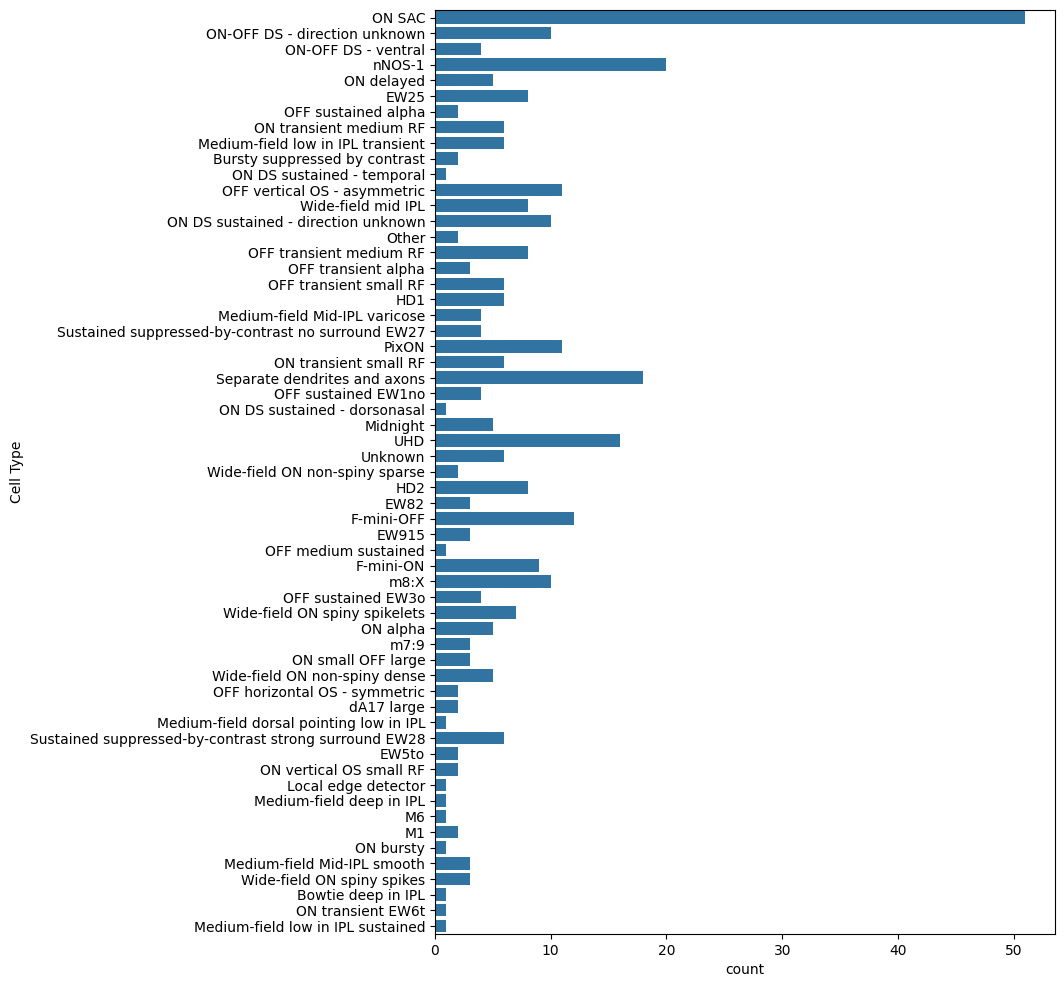

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df, y='Cell Type')
plt.show()

# Plot

In [7]:
%%time
from style import set_rc_params

set_rc_params()

CPU times: total: 0 ns
Wall time: 3.04 ms


In [8]:
%%time
fig_dir = f'../figures/calcium_data'
os.makedirs(fig_dir, exist_ok=True)

CPU times: total: 0 ns
Wall time: 312 μs


In [9]:
import plot
from skeleton import rotate_skel
import skeliner as sk

In [10]:
def plot_cells(df):
    fig, axs = plt.subplots(len(df), 5, figsize=(6, len(df) * 0.8), width_ratios=(0.9, 0.5, 1.6, 1.6, 0.6))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    all_xmin, all_xmax = [], []
    all_ymin, all_ymax = [], []
    
    for seg_id, row in df.iterrows():
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
    
        nodes = skel_rot.nodes[skel_rot.ntype == 3]
        nodes -= skel_rot.soma.center
        
        xmax, ymax, zmax = np.max(nodes, axis=0)
        xmin, ymin, zmin = np.min(nodes, axis=0)
    
        all_xmin.append(xmin)
        all_xmax.append(xmax)
        all_ymin.append(ymin)
        all_ymax.append(ymax)
    
    # Compute global limits with padding
    global_xlim = (min(all_xmin) - 13, max(all_xmax) + 3)
    global_ylim = (min(all_ymin) - 3, max(all_ymax) + 3)
    
    for i, (seg_id, row) in enumerate(df.iterrows()):
        ax = axs[i, 0]
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
        skel_rot.nodes -= skel_rot.soma.center

        sk.plot.projection(skel_rot,
                           ax=ax, xlim=global_ylim, ylim=global_xlim, plane='yx', draw_cylinders=False)
        plot.plot_scale_bar(ax=ax, x0=global_ylim[0] + 5, y0=np.mean(global_xlim),
                            size=100, text=False, unit='µm', tdist=0, orientation='v')
        ax.set_rasterized(True)

        ax = axs[i, 1]
        plot.plot_ipl_profile(ax=ax, row=row)

        ax = axs[i, 2]
        plot.plot_chirp(ax=ax, row=row)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 3]
        plot.plot_bar(ax=ax, row=row, annotate_dirs=False, annotate_symbols=i == 0, ventral_up=False)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 4]
        plot.plot_bar_dir(ax=ax, row=row, ventral_up=False)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')
        ax.set_facecolor((1, 1, 1, 0))

    plt.tight_layout(h_pad=0.5, w_pad=0.5)
    return fig, axs

In [11]:
df['swc_path'] = ''
df['skel'] = None

In [12]:
skel_dir = os.path.join(data_root, 'swc')
print(skel_dir)

../../huggingface/eyewire2-data\swc


In [13]:
def add_skels(df):
    df = df.copy()
    df['swc_path'] = df['Latest SegID'].apply(lambda x: os.path.join(skel_dir, f"{x}.swc"))
    df['skel'] = df.apply(lambda row: sk.io.load_swc(row['swc_path']) if os.path.isfile(row['swc_path']) else None, axis=1)
    return df

In [14]:
nuc_col_master = 'Latest NucID'

In [15]:
df.loc[df['Cell Type'] == 'ON alpha', 'Latest NucID'].values.astype(int)

array([720575940557717614, 720575940562660177, 720575940562274734,
       720575940562905653, 720575940559161547])

df_type.shape=(4, 144)
[720575940563641563 720575940562911131 720575940553949222
 720575940572157287]
df_type.shape=(4, 144)
           Latest SegID        Latest NucID Cell Type  chirp_qidx  bar_qidx
75   720575940563641563  720575940557717614  ON alpha    0.782221  0.989530
112  720575940562911131  720575940562660177  ON alpha    0.510090  0.945566
220  720575940553949222  720575940562274734  ON alpha    0.617054  0.985260
361  720575940572157287  720575940562905653  ON alpha    0.861580  0.980264
############################################################
All


[Info] scikit-sparse not found. Falling back to scipy.sparse.linalg.spsolve.


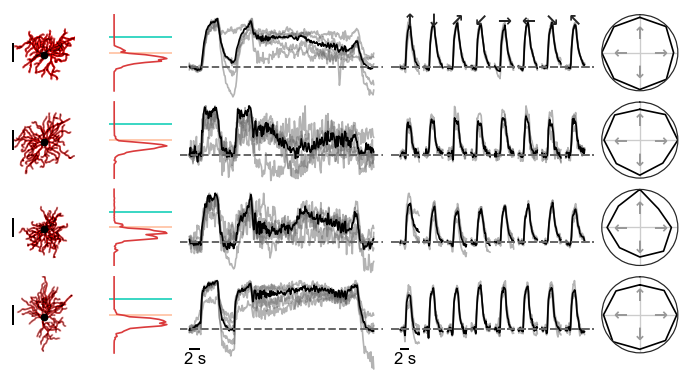

############################################################
Subset for figure


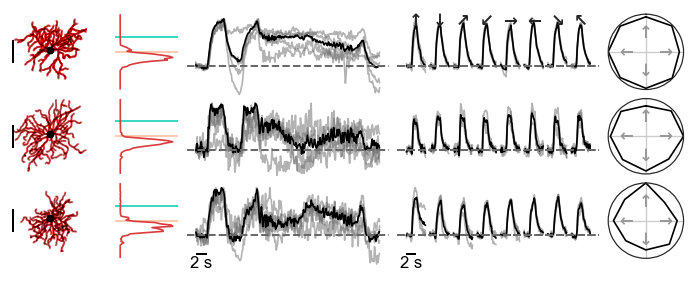

In [16]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5112165299126272

# Confirmed cell type final
son_alpha_nuc_ids = [  
    720575940557717614,
    720575940562274734,
    720575940562660177,
    720575940562905653,
]

df_type = add_skels(df[
    (df[nuc_col_master].astype(int).isin(son_alpha_nuc_ids))
    & ((df.chirp_qidx > 0.45) | (df.bar_qidx > 0.6))
    & (df["Status"] == 'Complete')
])
print(f"{df_type.shape=}")
print(df_type['Latest SegID'].values.astype(int))
df_type = df_type[df_type.skel.notnull()]
print(f"{df_type.shape=}")

print(df_type[['Latest SegID', 'Latest NucID', 'Cell Type', 'chirp_qidx', 'bar_qidx']])

if len(df_type) > 3:
    print('#' * 60)
    print('All')
    
    fig, axs = plot_cells(df_type)
    plt.show()
    
    print('#' * 60)
    print('Subset for figure')

fig, axs = plot_cells(df_type.iloc[:3])
plt.savefig(f'{fig_dir}/examples_son_alphas.svg', transparent=True, dpi=600)
plt.show()

df_type.shape=(11, 144)
[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940575771261 720575940583667923
 720575940547919816 720575940564157175 720575940561194713
 720575940553084567 720575940560950763]
df_type.shape=(11, 144)
           Latest SegID        Latest NucID Cell Type  chirp_qidx  bar_qidx
46   720575940563265819  720575940545435331       UHD    0.197359  0.690605
51   720575940572551485  720575940548138586       UHD    0.229675  0.801076
55   720575940576369093  720575940564590232       UHD    0.171436  0.606416
91   720575940562015742  720575940549780957       UHD    0.219006  0.610223
97   720575940575771261  720575940558911421       UHD    0.172436  0.849763
106  720575940583667923  720575940555457712       UHD    0.282532  0.854814
164  720575940547919816  720575940557456528       UHD    0.365162  0.850915
168  720575940564157175  720575940552304202       UHD    0.159878  0.601609
183  720575940561194713  720575940558194576       UHD 

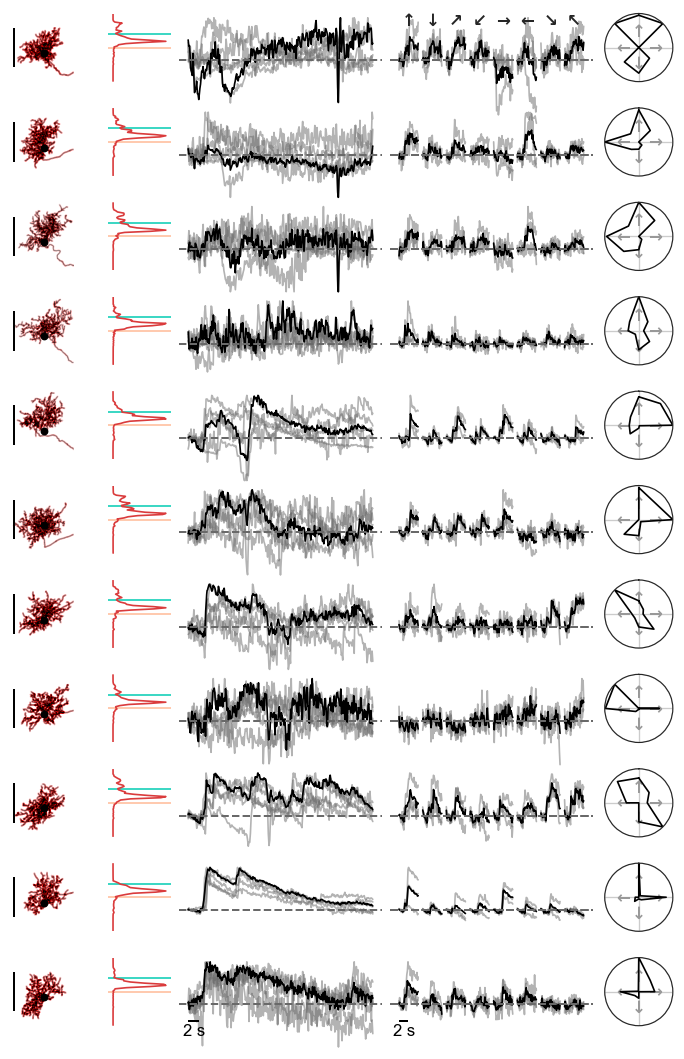

############################################################
Subset for figure


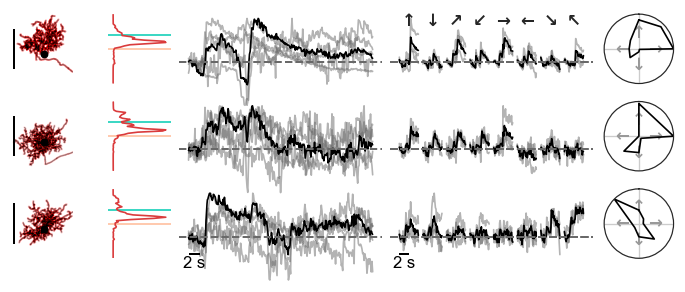

In [17]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5838312064417792

# Confirmed cell type final
uhd_list = [
    720575940568770345, 720575940557456528, 720575940581964854,
    720575940561165380, 720575940558194576, 720575940549780957,
    720575940545435331, 720575940552304202, 720575940562377319,
    720575940548138586, 720575940554823070, 720575940558911421,
    720575940564590232, 720575940555457712
]

df_type = add_skels(df[
    (df[nuc_col_master].astype(int).isin(uhd_list))
    & ((df.chirp_qidx > 0.45) | (df.bar_qidx > 0.6))
    & (df["Status"] == 'Complete')
])
print(f"{df_type.shape=}")
print(df_type['Latest SegID'].values.astype(int))
df_type = df_type[df_type.skel.notnull()]
print(f"{df_type.shape=}")

print(df_type[['Latest SegID', 'Latest NucID', 'Cell Type', 'chirp_qidx', 'bar_qidx']])

if len(df_type) > 3:
    print('#' * 60)
    print('All')
    
    fig, axs = plot_cells(df_type)
    plt.show()
    
    print('#' * 60)
    print('Subset for figure')

fig, axs = plot_cells(df_type.iloc[4:7])
plt.savefig(f'{fig_dir}/examples_uhd.svg', transparent=True, dpi=600)
plt.show()